In [9]:
import pandas as pd
import numpy as np
import nltk
import re

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [10]:
# Upload file
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv("tennis.csv")

# Sentence tokenize
sentences = []
for s in df['article_text']:
    sentences.append(sent_tokenize(str(s)))

sentences = [y for x in sentences for y in x]

Saving tennis.csv to tennis (4).csv


In [13]:
df

,article_id,article_text,source
0,1,Maria Sharapova has basically no friends as te...,https://www.tennisworldusa.org/tennis/news/Mar...
1,2,"BASEL, Switzerland (AP), Roger Federer advance...",http://www.tennis.com/pro-game/2018/10/copil-s...
2,3,Roger Federer has revealed that organisers of ...,https://scroll.in/field/899938/tennis-roger-fe...
3,4,Kei Nishikori will try to end his long losing ...,http://www.tennis.com/pro-game/2018/10/nishiko...
4,5,"Federer, 37, first broke through on tour over ...",https://www.express.co.uk/sport/tennis/1036101...
5,6,Nadal has not played tennis since he was force...,https://www.express.co.uk/sport/tennis/1037119...
6,7,"Tennis giveth, and tennis taketh away. The end...",http://www.tennis.com/pro-game/2018/10/tennisc...
7,8,Federer won the Swiss Indoors last week by bea...,https://www.express.co.uk/sport/tennis/1038186...


In [14]:
# Clean text
clean_sentences = pd.Series(sentences).str.replace("[^a-zA-Z]", " ", regex=True)
clean_sentences = [s.lower() for s in clean_sentences]

stop_words = stopwords.words('english')

def remove_stopwords(sen):
    return " ".join([i for i in sen if i not in stop_words])

clean_sentences = [remove_stopwords(r.split()) for r in clean_sentences]

In [15]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(clean_sentences)

In [16]:
# Similarity matrix
sim_mat = cosine_similarity(X)

In [21]:
# PageRank
nx_graph = nx.from_numpy_array(sim_mat)
scores = nx.pagerank(nx_graph)

In [18]:
# Ranking sentences
ranked_sentences = sorted(
    ((scores[i], s) for i, s in enumerate(sentences)),
    reverse=True
)

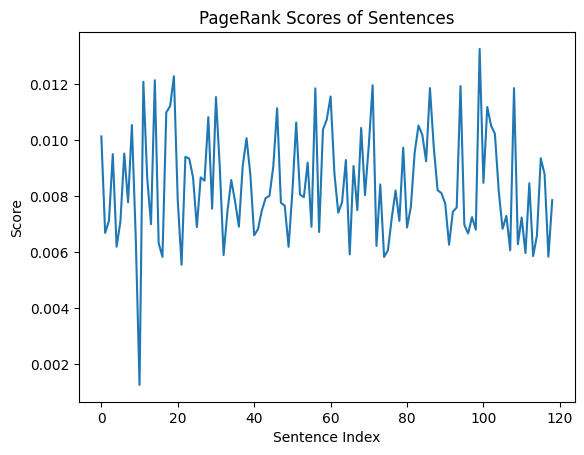

In [22]:
import matplotlib.pyplot as plt
# scores dictionary → list
values = list(scores.values())

plt.figure()
plt.plot(values)
plt.title("PageRank Scores of Sentences")
plt.xlabel("Sentence Index")
plt.ylabel("Score")
plt.show()

In [19]:
# Show summary
for i in range(8):
    print("ARTICLE:")
    print(df['article_text'][i])
    print("\nSUMMARY:")
    print(ranked_sentences[i][1])
    print("\n")

ARTICLE:
Maria Sharapova has basically no friends as tennis players on the WTA Tour. The Russian player has no problems in openly speaking about it and in a recent interview she said: 'I don't really hide any feelings too much. I think everyone knows this is my job here. When I'm on the courts or when I'm on the court playing, I'm a competitor and I want to beat every single person whether they're in the locker room or across the net.So I'm not the one to strike up a conversation about the weather and know that in the next few minutes I have to go and try to win a tennis match. I'm a pretty competitive girl. I say my hellos, but I'm not sending any players flowers as well. Uhm, I'm not really friendly or close to many players. I have not a lot of friends away from the courts.' When she said she is not really close to a lot of players, is that something strategic that she is doing? Is it different on the men's tour than the women's tour? 'No, not at all. I think just because you're in t